# Infraslow sigma-power spectrum — old vs. fixed, subject 318658, C3

`infraslow.processing.subject_pipeline.calculate_stage_events` used to build the
per-bout infraslow spectrum from a **spindle-rate series** (detector-derived) instead
of the **sigma-power envelope** (`power_envelope` -> `infraslow_spectrum`) that
`demo_infraslow_yasa.ipynb` / `demo_infraslow_yasa_average.ipynb` use. That's now fixed
to match the reference notebooks.

This reproduces Fig **C-i) Baseline-corrected + Gaussian fit** (see
`demo_infraslow_yasa.ipynb`) for subject `318658`, channel `C3`, stage `N2` -- once
from the **old** (spindle-rate, pre-fix) npz and once from the **new** (sigma-power,
post-fix) npz -- so the two can be compared side by side.

Both spectra are read directly from the pipeline's own `.npz` output
(`{channel}__spectra__freqs` / `{channel}__spectra__corr_mean`), which is already the
bout-averaged, unit-band-area-normalized, baseline-corrected relative spectrum -- so no
raw EDF, hypnogram, or bout-finding is needed here, only the two spectra and a fresh
Gaussian ISFS fit (matching `demo_infraslow_yasa.ipynb`'s `fit_isfs`).

In [5]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from infraslow.processing.subject_pipeline import INFRASLOW_BAND, BASELINE_BAND

plt.rcParams['figure.dpi'] = 110
PURPLE, LPURPLE = '#5b2a86', '#c9b3e6'
OLD_COLOR, NEW_COLOR = '0.4', '#1f77b4'
_trapz = getattr(np, 'trapezoid', np.trapz)   # NumPy 2.0 renamed trapz

## Load both npz spectra (C3, N2)

In [6]:
SUBJECT = '318658'
CHANNEL = 'C3'
STAGE = 'N2'

# 'old' = pre-fix production output (spindle-rate-derived spectrum).
# 'new' = post-fix verification run (sigma-power-envelope-derived spectrum);
# see infraslow.processing.subject_pipeline.calculate_stage_events.
OLD_NPZ = Path(os.path.expandvars(f'$SCRATCH/results_v2/npz/{STAGE}/{SUBJECT}.npz'))
NEW_NPZ = Path(os.path.expandvars(f'$SCRATCH/verify_318658/npz/{STAGE}/{SUBJECT}.npz'))


def load_channel_spectrum(npz_path, channel):
    with np.load(npz_path) as npz:
        return npz[f'{channel}__spectra__freqs'], npz[f'{channel}__spectra__corr_mean']


freqs_old, corr_old = load_channel_spectrum(OLD_NPZ, CHANNEL)
freqs_new, corr_new = load_channel_spectrum(NEW_NPZ, CHANNEL)
assert np.array_equal(freqs_old, freqs_new), 'old/new frequency grids differ -- not comparable'
freqs = freqs_old
band_m = (freqs >= INFRASLOW_BAND[0]) & (freqs <= INFRASLOW_BAND[1])
print(f'{SUBJECT} {CHANNEL} {STAGE}: {freqs.size} frequency bin(s), '
      f'{band_m.sum()} within {INFRASLOW_BAND} Hz')

318658 C3 N2: 51 frequency bin(s), 10 within (0.01, 0.1) Hz


## Gaussian ISFS fit (matches `demo_infraslow_yasa.ipynb`'s `fit_isfs`)

In [7]:
def gaussian(f, amp, mu, sd):
    return amp * np.exp(-0.5 * ((f - mu) / sd) ** 2)


def fit_isfs(freqs, corrected, infraslow_band=INFRASLOW_BAND, baseline_band=BASELINE_BAND):
    """Fig C-i parameters from an already baseline-corrected relative spectrum."""
    base_m = (freqs >= baseline_band[0]) & (freqs <= baseline_band[1])
    fit_m = (freqs >= infraslow_band[0]) & (freqs < baseline_band[0])
    ff, yy = freqs[fit_m], corrected[fit_m]
    p0 = [max(yy.max(), 1e-9), ff[np.argmax(yy)], 0.01]
    popt, _ = curve_fit(gaussian, ff, yy, p0=p0,
                        bounds=([0, infraslow_band[0], 1e-3], [np.inf, baseline_band[0], 0.05]),
                        maxfev=10000)
    amp, mu, sd = popt
    lo, hi = mu - sd, mu + sd            # +/-1 SD around the peak frequency
    bandwidth = hi - lo                  # = 2*sd (variability in period)
    f_auc = np.linspace(lo, hi, 400)     # fine grid: coarse PSD bins undercount the area
    auc = float(_trapz(gaussian(f_auc, *popt), f_auc))   # power within the SAME +/-1 SD range
    threshold = 1.5 * corrected[base_m].std()   # 1.5x SD of the baseline-band (noise) spectrum
    return dict(popt=popt, amp=amp, mu=mu, sd=sd, lo=lo, hi=hi,
                bandwidth=bandwidth, auc=auc,
                threshold=threshold, detected=bool(amp > threshold))


fit_old = fit_isfs(freqs, corr_old)
fit_new = fit_isfs(freqs, corr_new)
for label, fit in (('old (spindle-rate)', fit_old), ('new (sigma-power)', fit_new)):
    print(f"{label:22s}: detected={fit['detected']!s:5} | peak {fit['mu']:.4f} Hz "
          f"(~{1/fit['mu']:.0f} s) | bandwidth {fit['bandwidth']:.4f} Hz | AUC {fit['auc']:.3g}")

old (spindle-rate)    : detected=True  | peak 0.0140 Hz (~72 s) | bandwidth 0.0184 Hz | AUC 1.05
new (sigma-power)     : detected=True  | peak 0.0264 Hz (~38 s) | bandwidth 0.0247 Hz | AUC 0.123


## Figure C-i) Baseline-corrected + Gaussian fit — old vs. new, side by side

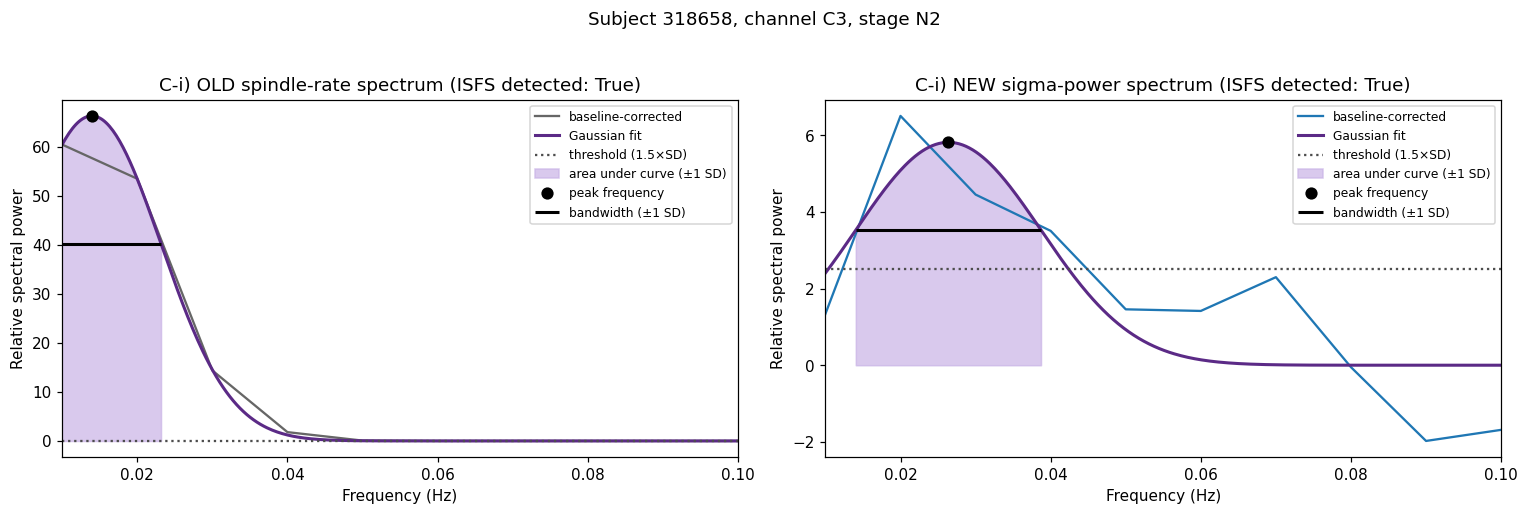

In [8]:
def plot_ci_panel(ax, freqs, corrected, fit, *, color, title):
    """One C-i right-panel: baseline-corrected spectrum + Gaussian fit + ISFS params
    (matches demo_infraslow_yasa.ipynb's Fig C-i right panel)."""
    ax.plot(freqs[band_m], corrected[band_m], color=color, lw=1.5, label='baseline-corrected')
    fg = np.linspace(*INFRASLOW_BAND, 400)
    ax.plot(fg, gaussian(fg, *fit['popt']), color=PURPLE, lw=2, label='Gaussian fit')
    ax.axhline(fit['threshold'], ls=':', color='0.3', label='threshold (1.5×SD)')
    f_auc = np.linspace(fit['lo'], fit['hi'], 400)
    ax.fill_between(f_auc, gaussian(f_auc, *fit['popt']), color=LPURPLE, alpha=0.7,
                    label='area under curve (±1 SD)')
    ax.plot([fit['mu']], [gaussian(fit['mu'], *fit['popt'])], 'o', color='k', ms=7, zorder=5,
            label='peak frequency')
    ax.hlines(gaussian(fit['lo'], *fit['popt']), fit['lo'], fit['hi'], color='k', lw=2,
              label='bandwidth (±1 SD)')
    ax.set(xlim=INFRASLOW_BAND, xlabel='Frequency (Hz)', ylabel='Relative spectral power',
           title=title)
    ax.legend(frameon=True, fontsize=8)


fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.5))
plot_ci_panel(axL, freqs, corr_old, fit_old, color=OLD_COLOR,
              title=f"C-i) OLD spindle-rate spectrum (ISFS detected: {fit_old['detected']})")
plot_ci_panel(axR, freqs, corr_new, fit_new, color=NEW_COLOR,
              title=f"C-i) NEW sigma-power spectrum (ISFS detected: {fit_new['detected']})")
fig.suptitle(f'Subject {SUBJECT}, channel {CHANNEL}, stage {STAGE}', y=1.03, fontsize=12)
fig.tight_layout()
plt.show()